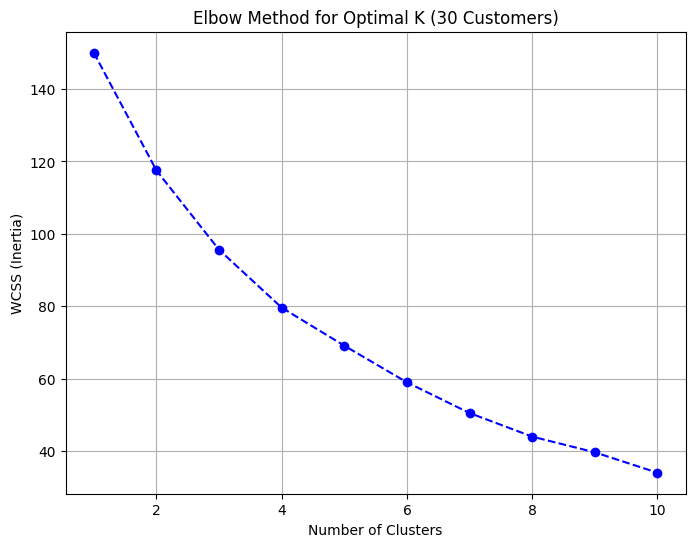


Clustered Data:
    CustomerID     Name  Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0            1    Aarav   56        456730                 14           8506   
1            2   Vihaan   46       1498079                 17           3068   
2            3   Ishaan   32        954811                  4           5963   
3            4    Kabir   60        827035                 18           2527   
4            5    Aryan   25        948143                  8           3195   
5            6    Anaya   38        365725                  4           5758   
6            7     Myra   56       1478557                  2           6118   
7            8   Aadhya   36        384654                  6           7236   
8            9     Siya   40       1253277                 10            891   
9           10     Riya   28        891723                  4           6392   
10          11     Neha   28        619030                 18           4061   
11          12    Rohan

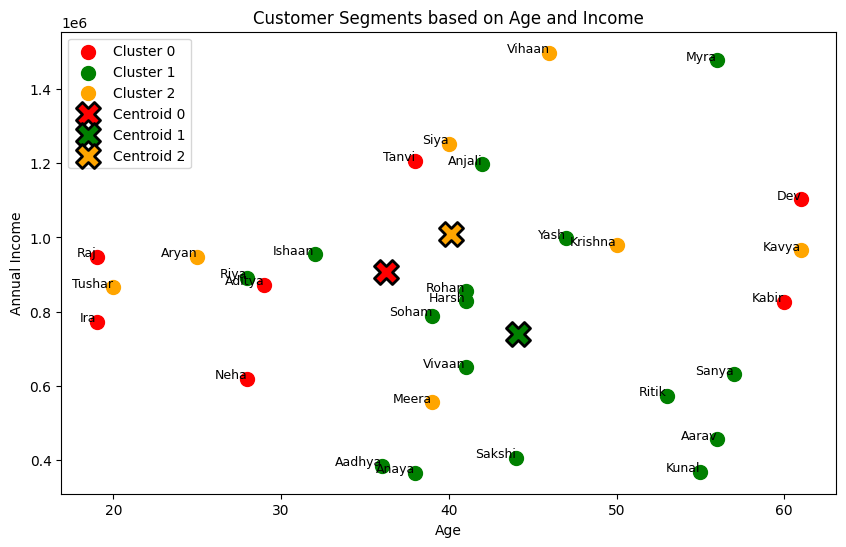

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic dataset for Flipkart customers (Only 30 customers)
np.random.seed(42)

customer_count = 30

# Sample Indian customer names
customer_names = [
    "Aarav", "Vihaan", "Ishaan", "Kabir", "Aryan", "Anaya", "Myra", "Aadhya", "Siya", "Riya",
    "Neha", "Rohan", "Ritik", "Sanya", "Harsh", "Tushar", "Soham", "Ira", "Vivaan", "Kavya",
    "Yash", "Kunal", "Raj", "Tanvi", "Krishna", "Aditya", "Meera", "Dev", "Anjali", "Sakshi"
]

# Generating random customer data
age = np.random.randint(18, 65, customer_count)
annual_income = np.random.randint(300000, 1500000, customer_count)
purchase_frequency = np.random.randint(1, 20, customer_count)
avg_order_value = np.random.randint(500, 10000, customer_count)
preferred_category = np.random.choice(['Electronics', 'Fashion', 'HomeGoods', 'Groceries', 'Books'], customer_count)
discount_sensitivity = np.random.uniform(0.1, 1.0, customer_count)

# Create DataFrame
data = pd.DataFrame({
    'CustomerID': range(1, customer_count + 1),
    'Name': customer_names,
    'Age': age,
    'AnnualIncome': annual_income,
    'PurchaseFrequency': purchase_frequency,
    'AvgOrderValue': avg_order_value,
    'PreferredCategory': preferred_category,
    'DiscountSensitivity': discount_sensitivity
})

# Step 2: Preprocess the data (only numeric features for clustering)
numeric_data = data[['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K (30 Customers)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# Step 4: Apply K-Means with the selected number of clusters (K=3)
optimal_k = 3  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

# Step 5: Show the first few rows of the dataset with cluster labels
print("\nClustered Data:")
print(data)

# Step 6: Cluster insights (mean of numeric features within each cluster)
numeric_columns = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']
cluster_insights = data.groupby('Cluster')[numeric_columns].mean()

# Display the cluster insights
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)

# Step 7: Define action points based on clusters
action_points = {
    0: "💡 Offer premium membership & exclusive discounts!",
    1: "📢 Recommend budget-friendly deals & coupons!",
    2: "🎯 Promote high-value products with personalized ads!"
}

# Add action points based on cluster
data['ActionPoint'] = data['Cluster'].map(action_points)

# Step 8: Define cluster meanings based on characteristics
cluster_meanings = {
    0: "Premium Customers - High income, frequent purchases",
    1: "Budget-Conscious - Moderate income, low purchase frequency",
    2: "High-Spenders - High order values, willing to spend on quality"
}

# Add cluster meanings based on cluster
data['ClusterMeaning'] = data['Cluster'].map(cluster_meanings)

# Step 9: Display the data with cluster, action point, and cluster meaning
print("\nCustomer Segmentation with Action Points and Cluster Meaning:")
print(data[['Name', 'Cluster', 'ClusterMeaning', 'ActionPoint']].to_string(index=False))

# Step 10: Visualizing the Clusters (Age vs Annual Income)
plt.figure(figsize=(10, 6))

# Define distinct colors for clusters
cluster_colors = {0: 'red', 1: 'green', 2: 'orange'}  # Red, Green, Yellow/Orange

# Scatter plot of customers
for cluster, color in cluster_colors.items():
    cluster_data = data[data['Cluster'] == cluster]
    plt.scatter(cluster_data['Age'], cluster_data['AnnualIncome'], color=color, s=100, label=f'Cluster {cluster}')

# Mark centroids with the SAME colors as their respective clusters
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], marker='X', s=300, color=cluster_colors[i], edgecolors='black', linewidth=2, label=f'Centroid {i}')

# Add customer names to points
for i in range(customer_count):
    plt.text(data['Age'][i], data['AnnualIncome'][i], data['Name'][i], fontsize=9, ha='right')

plt.title('Customer Segments based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.legend()
plt.show()

In [ ]:
Expected Output:
1. Clustered Data:
After clustering, each customer will have a Cluster, Cluster Meaning, and Action Point associated with their data.
2. Cluster Insights:
Displays the mean values of the customer characteristics within each cluster.
3. Visualization:
Scatter plot of the clusters, showing how customers are distributed based on their Age and Annual Income, with centroid markers.
Intertia:
Centroid:

In [ ]:
# project2

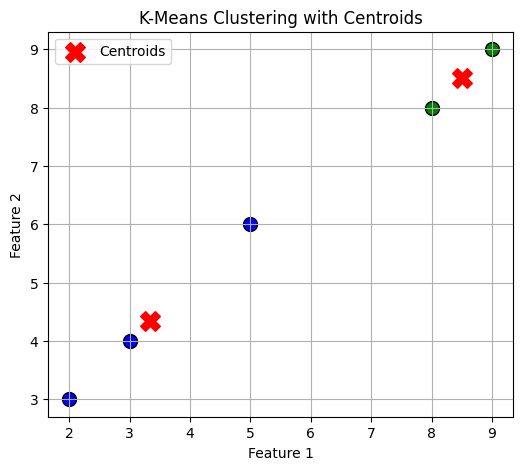

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Reference:
#https://scikit-learn.org/stable/modules/clustering.html#k-means

# Sample Data (2D Points)
data = np.array([[2, 3], [3, 4], [5, 6], [8, 8], [9, 9]])

# Applying K-Means with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(data)

# Get Cluster Labels and Centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot Data Points with Cluster Colors
plt.figure(figsize=(6, 5))
for i in range(len(data)):
    plt.scatter(data[i, 0], data[i, 1], c=['blue', 'green'][labels[i]], s=100, edgecolors='black')

# Plot Centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

# Labels and Legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering with Centroids")
plt.legend()
plt.grid()

# Show Plot
plt.show()

In [ ]:
Data Points:
(2, 3), (3, 4), (5, 6)
Centroid Calculation:
Centroid = (2+3+5)/3, (3+4+6)/3 = 10/3, 13/3 = (3.33, 4.33)

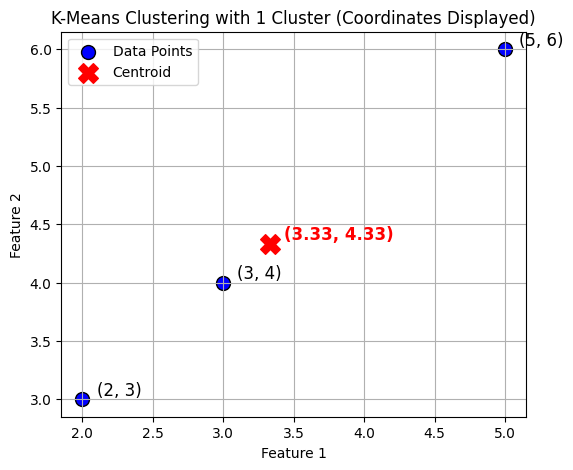

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample Data (2D Points)
data = np.array([[2, 3], [3, 4], [5, 6]])

# Applying K-Means with K=1 (Only One Cluster)
kmeans = KMeans(n_clusters=1, random_state=42, n_init=10)
kmeans.fit(data)

# Get Cluster Labels and Centroids
centroid = kmeans.cluster_centers_

# Plot Data Points
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], c='blue', s=100, edgecolors='black', label='Data Points')

# Annotate Data Points with Coordinates
for x, y in data:
    plt.text(x + 0.1, y, f"({x}, {y})", fontsize=12, verticalalignment='bottom', color='black')

# Plot Centroid
plt.scatter(centroid[:, 0], centroid[:, 1], c='red', marker='X', s=200, label='Centroid')

# Annotate Centroid with Coordinates
plt.text(centroid[0, 0] + 0.1, centroid[0, 1], f"({centroid[0, 0]:.2f}, {centroid[0, 1]:.2f})",
         fontsize=12, verticalalignment='bottom', color='red', fontweight='bold')

# Labels and Legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering with 1 Cluster (Coordinates Displayed)")
plt.legend()
plt.grid()
plt.show()  # Show Plot

In [5]:
import numpy as np

# Sample Data
data = np.array([[2, 3], [3, 4], [5, 6]])

# Centroid Calculation (Mean of all points)
centroid = np.mean(data, axis=0)

# Compute Sum of Squared Distances (SSD)
ssd = np.sum(np.linalg.norm(data - centroid, axis=1) ** 2)

print("Manually Computed Inertia (SSD):", ssd)
# Manually Computed Inertia (SSD): 9.333333333333334
import numpy as np

# Sample Data
data = np.array([[2, 3], [3, 4], [5, 6]])

# Step 1: Calculate Centroid
centroid = np.mean(data, axis=0)
print(f"Centroid: ({centroid[0]:.2f}, {centroid[1]:.2f})\n")

# Step 2: Compute Squared Euclidean Distance for Each Point
ssd = 0  # Initialize Sum of Squared Distances
for i, point in enumerate(data):
    distance = np.linalg.norm(point - centroid)  # Euclidean Distance
    squared_distance = distance ** 2  # Squared Distance
    ssd += squared_distance  # Add to Sum of Squared Distances

    print(f"Point {i+1}: {point}, Distance to Centroid: {distance:.4f}, Squared Distance: {squared_distance:.4f}")

# Step 3: Display Total Inertia
print(f"\nTotal Inertia (Sum of Squared Distances - SSD): {ssd:.4f}")


Manually Computed Inertia (SSD): 9.333333333333334
Centroid: (3.33, 4.33)

Point 1: [2 3], Distance to Centroid: 1.8856, Squared Distance: 3.5556
Point 2: [3 4], Distance to Centroid: 0.4714, Squared Distance: 0.2222
Point 3: [5 6], Distance to Centroid: 2.3570, Squared Distance: 5.5556

Total Inertia (Sum of Squared Distances - SSD): 9.3333


In [ ]:
Centroid: (3.33, 4.33)

Point 1: [2 3], Distance to Centroid: 1.8856, Squared Distance: 3.5556
Point 2: [3 4], Distance to Centroid: 0.4714, Squared Distance: 0.2222
Point 3: [5 6], Distance to Centroid: 2.3570, Squared Distance: 5.5556

Total Inertia (Sum of Squared Distances - SSD): 9.3333

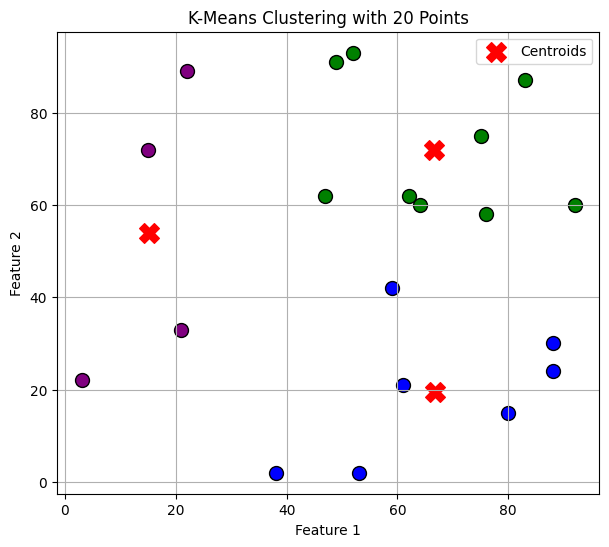

In [6]:
import pandas as pd
import numpy as np

# Generate 20 random 2D points for a more practical example
np.random.seed(42)
data = np.random.randint(1, 100, (20, 2))

# Applying K-Means with K=3 (3 clusters for better visualization)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(data)

# Get Cluster Labels and Centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot Data Points with Cluster Colors
plt.figure(figsize=(7, 6))
colors = ['blue', 'green', 'purple']
for i in range(len(data)):
    plt.scatter(data[i, 0], data[i, 1], c=colors[labels[i]], s=100, edgecolors='black')

# Plot Centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')

# Labels and Legend
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering with 20 Points")
plt.legend()
plt.grid()

# Show Plot
plt.show()


# THE END